In [1]:
!pip install -q chronos-forecasting

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.6/80.6 kB 3.5 MB/s eta 0:00:00


# VERİ

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.deterministic import DeterministicProcess
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from chronos import ChronosPipeline

np.random.seed(0)
torch.manual_seed(0)

data = sm.datasets.co2.load_pandas().data
data.index = pd.to_datetime(data.index)
y = data["co2"].resample("MS").mean().interpolate().dropna()
y.index.freq = "MS"

H = 36
train, test = y.iloc[:-H], y.iloc[-H:]
results = {}

print(y.shape, train.shape, test.shape)
y.head()

(526,) (490,) (36,)


,co2
1958-03-01,316.100000
1958-04-01,317.200000
1958-05-01,317.433333
1958-06-01,316.529167
1958-07-01,315.625000


In [3]:
gamma = sm.tsa.acovf(train.values, nlag=36, fft=True)
rho = sm.tsa.acf(train.values, nlags=36, fft=True)
phi = sm.tsa.pacf(train.values, nlags=36)

pd.DataFrame({"gamma_k": gamma[:13], "rho_k": rho[:13], "phi_kk": phi[:13]})

,gamma_k,rho_k,phi_kk
0,243.238752,1.000000,1.000000
1,241.183825,0.991552,0.993580
2,238.267545,0.979562,-0.283071
3,235.071512,0.966423,-0.022653
4,232.127872,0.954321,0.112049
5,229.661328,0.944181,0.107281
6,227.779939,0.936446,0.112280
7,226.491113,0.931147,0.114138
8,225.893991,0.928692,0.171006
9,225.947408,0.928912,0.168006


In [4]:
d1 = train.diff().dropna()
d12 = d1.diff(12).dropna()

pd.DataFrame(
    [
        {"seri": "y_t", "adf": adfuller(train)[0], "p": adfuller(train)[1]},
        {"seri": "d1_y_t", "adf": adfuller(d1)[0], "p": adfuller(d1)[1]},
        {"seri": "d12_d1_y_t", "adf": adfuller(d12)[0], "p": adfuller(d12)[1]},
    ]
).set_index("seri")

,adf,p
seri,,
y_t,2.579823,9.990711e-01
d1_y_t,-3.577328,6.209548e-03
d12_d1_y_t,-7.976011,2.701250e-12


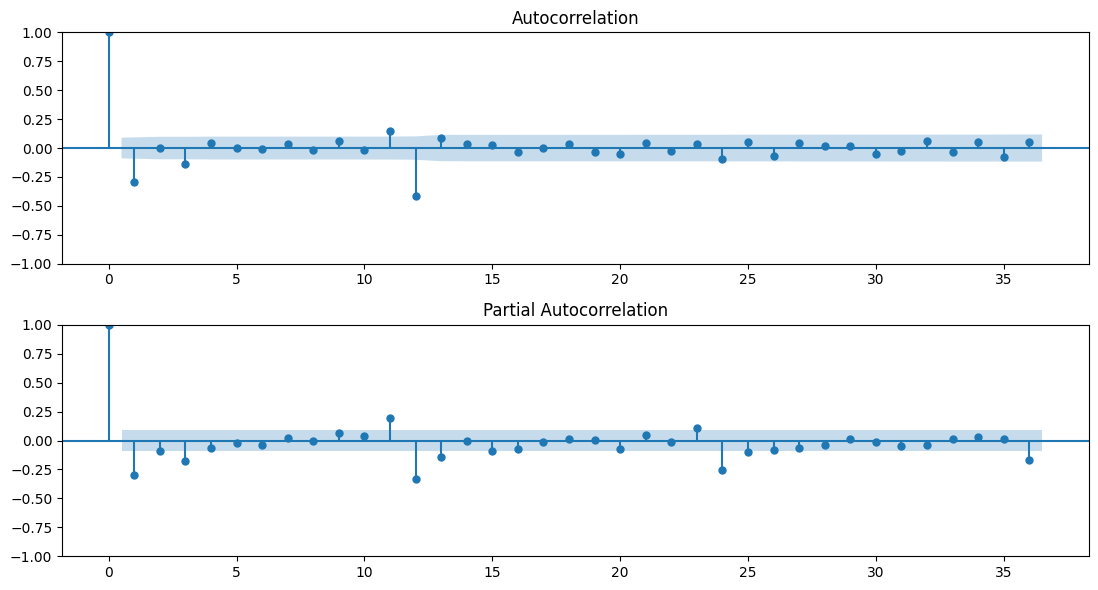

In [5]:
fig, ax = plt.subplots(2, 1, figsize=(11, 6))
sm.graphics.tsa.plot_acf(d12, lags=36, ax=ax[0])
sm.graphics.tsa.plot_pacf(d12, lags=36, ax=ax[1], method="ywm")
plt.tight_layout()
plt.show()

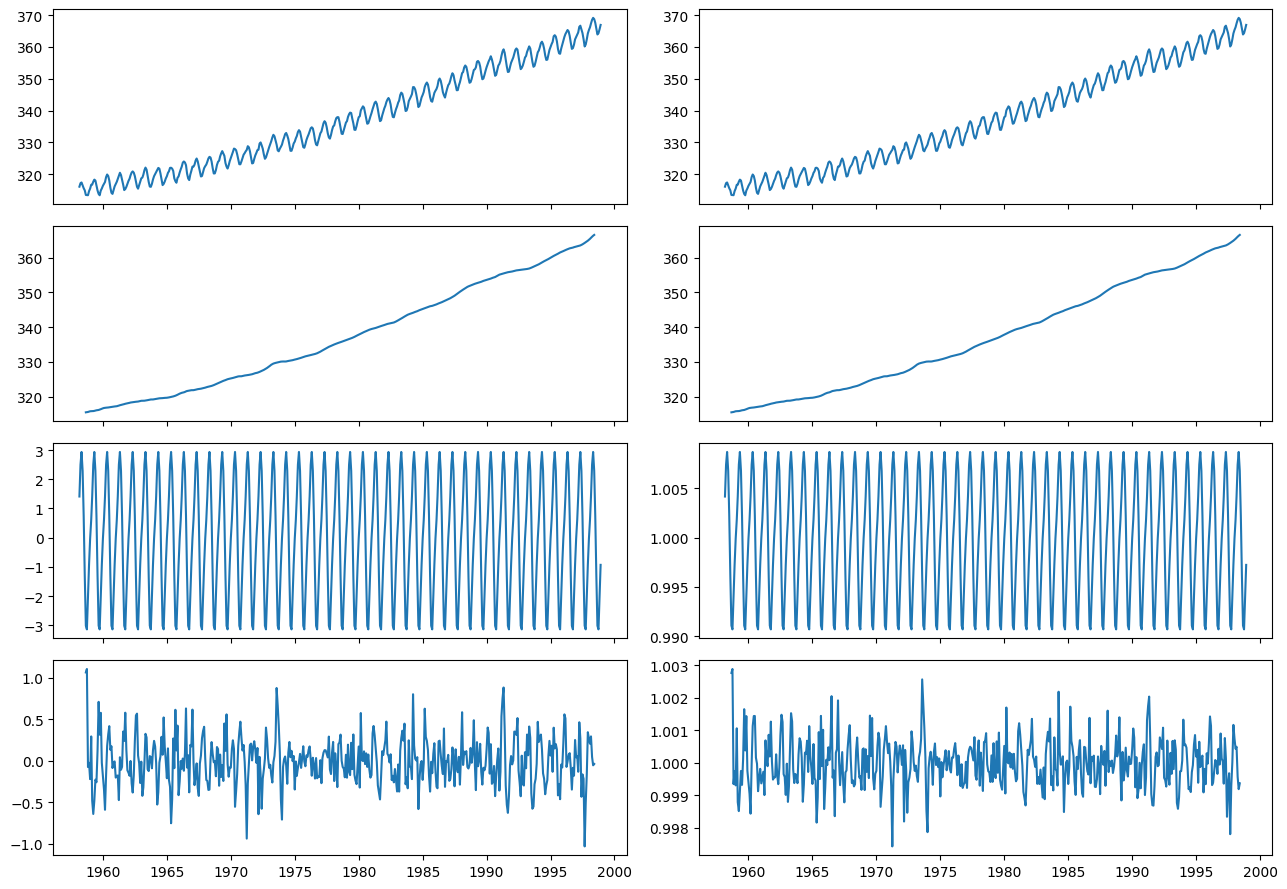

In [6]:
add = seasonal_decompose(train, model="additive", period=12)
mul = seasonal_decompose(train, model="multiplicative", period=12)

fig, ax = plt.subplots(4, 2, figsize=(13, 9), sharex=True)
for j, dec in enumerate([add, mul]):
    ax[0, j].plot(dec.observed)
    ax[1, j].plot(dec.trend)
    ax[2, j].plot(dec.seasonal)
    ax[3, j].plot(dec.resid)
plt.tight_layout()
plt.show()

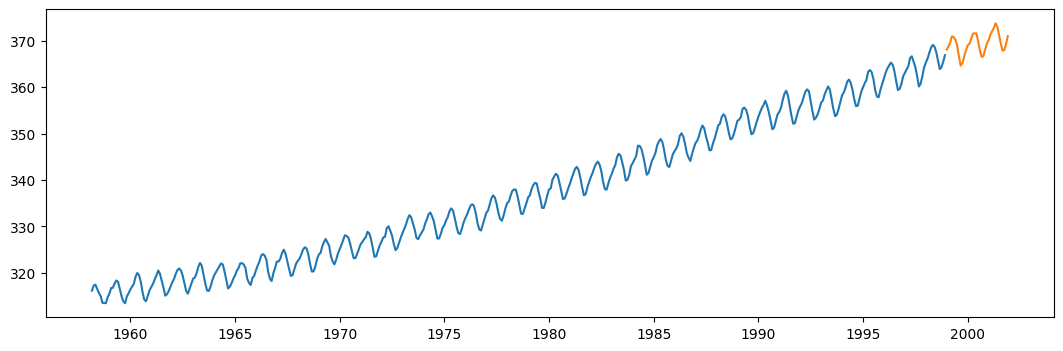

In [7]:
plt.figure(figsize=(13, 4))
plt.plot(train.index, train.values)
plt.plot(test.index, test.values)
plt.show()

# MODEL

## Deterministik

In [8]:
dp = DeterministicProcess(index=train.index, constant=True, order=1, seasonal=True)
X_tr = dp.in_sample()
X_te = dp.out_of_sample(H)

det = sm.OLS(train.values, X_tr.values).fit()
results["Deterministik"] = pd.Series(det.predict(X_te.values), index=test.index)
results["Deterministik"].head()

,0
1999-01-01,364.039719
1999-02-01,364.797636
1999-03-01,365.793324
1999-04-01,366.987999
1999-05-01,367.521983


## Stokastik

In [9]:
sarima = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)).fit(disp=False)
pred = sarima.get_forecast(H).predicted_mean
pred.index = test.index

results["Stokastik"] = pred
results["Stokastik"].head()

,predicted_mean
1999-01-01,367.995931
1999-02-01,368.814255
1999-03-01,369.787756
1999-04-01,371.060742
1999-05-01,371.600354


## ShallowML

In [10]:
L = 24
dtrain = train.diff().dropna().values


def lag_matrix(v, lags):
    X = np.column_stack([v[i:len(v) - lags + i] for i in range(lags)])
    return X, v[lags:]


X, target = lag_matrix(dtrain, L)
rf = RandomForestRegressor(n_estimators=500, random_state=0).fit(X, target)

window = list(dtrain[-L:])
level = train.values[-1]
path = []
for _ in range(H):
    delta = rf.predict(np.array(window[-L:]).reshape(1, -1))[0]
    level = level + delta
    path.append(level)
    window.append(delta)

results["ShallowML"] = pd.Series(path, index=test.index)
results["ShallowML"].head()

,0
1999-01-01,367.902127
1999-02-01,368.770763
1999-03-01,369.761960
1999-04-01,370.869637
1999-05-01,371.245280


## DeepML

In [11]:
mu, sd = dtrain.mean(), dtrain.std()
z = (dtrain - mu) / sd
Xz, tz = lag_matrix(z, L)
Xt = torch.tensor(Xz, dtype=torch.float32).unsqueeze(-1)
tt = torch.tensor(tz, dtype=torch.float32).unsqueeze(-1)


class LSTMForecaster(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.encoder = nn.LSTM(1, hidden, batch_first=True)
        self.head = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.encoder(x)
        return self.head(out[:, -1, :])


net = LSTMForecaster()
opt = torch.optim.Adam(net.parameters(), lr=1e-3)
mse = nn.MSELoss()

for epoch in range(400):
    opt.zero_grad()
    loss = mse(net(Xt), tt)
    loss.backward()
    opt.step()

net.eval()
window = list(z[-L:])
level = train.values[-1]
path = []
with torch.no_grad():
    for _ in range(H):
        x = torch.tensor(np.array(window[-L:]), dtype=torch.float32).view(1, L, 1)
        dz = net(x).item()
        level = level + dz * sd + mu
        path.append(level)
        window.append(dz)

results["DeepML"] = pd.Series(path, index=test.index)
print(loss.item())
results["DeepML"].head()

0.06682680547237396


,0
1999-01-01,367.903035
1999-02-01,368.674525
1999-03-01,369.632128
1999-04-01,370.828958
1999-05-01,371.264049


## Foundation

In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small", device_map=device, torch_dtype=torch.float32
)

context = torch.tensor(train.values, dtype=torch.float32)
samples = pipeline.predict(context, prediction_length=H, num_samples=100)

results["Foundation"] = pd.Series(np.median(samples[0].numpy(), axis=0), index=test.index)
results["Foundation"].head()

config.json:   0%|          | 0.00/1.11k [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B /  185MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

,0
1999-01-01,368.595154
1999-02-01,368.595154
1999-03-01,368.595154
1999-04-01,371.068939
1999-05-01,371.068939


## Headed

In [13]:
C = 64
v = train.values.astype(np.float32)
windows = np.stack([v[i:i + C] for i in range(len(v) - C)])
labels = v[C:]


def encode(batch):
    with torch.no_grad():
        emb, scale = pipeline.embed(torch.tensor(batch, dtype=torch.float32))
    return emb.mean(dim=1).float().numpy(), scale.float().cpu().numpy()


Z, S = [], []
for i in range(0, len(windows), 64):
    e, s = encode(windows[i:i + 64])
    Z.append(e)
    S.append(s)
Z, S = np.concatenate(Z), np.concatenate(S)

head = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 4, 13)))
head.fit(Z, labels / S)

buffer = list(v)
path = []
for _ in range(H):
    e, s = encode(np.array(buffer[-C:], dtype=np.float32).reshape(1, -1))
    nxt = float(head.predict(e)[0] * s[0])
    path.append(nxt)
    buffer.append(nxt)

results["Headed"] = pd.Series(path, index=test.index)
print(Z.shape)
results["Headed"].head()

(426, 512)


,0
1999-01-01,367.930749
1999-02-01,369.197123
1999-03-01,369.863792
1999-04-01,370.512266
1999-05-01,371.403619


# DEĞERLENDİRME

In [14]:
def score(actual, pred):
    return {
        "MAE": mean_absolute_error(actual, pred),
        "RMSE": np.sqrt(mean_squared_error(actual, pred)),
        "MAPE": np.mean(np.abs((actual - pred) / actual)) * 100,
    }


scores = pd.DataFrame(
    {name: score(test.values, np.asarray(pred, dtype=float)) for name, pred in results.items()}
).T
scores

,MAE,RMSE,MAPE
Deterministik,3.426081,3.442311,0.927169
Stokastik,0.995848,1.084532,0.269302
ShallowML,0.696502,0.773058,0.188500
DeepML,0.451241,0.507424,0.122206
Foundation,1.018443,1.288406,0.276059
Headed,0.481892,0.647319,0.130542


In [15]:
forecasts = pd.DataFrame(results, index=test.index)
forecasts.insert(0, "Gercek", test.values)
forecasts

,Gercek,Deterministik,Stokastik,ShallowML,DeepML,Foundation,Headed
1999-01-01,368.120,364.039719,367.995931,367.902127,367.903035,368.595154,367.930749
1999-02-01,368.850,364.797636,368.814255,368.770763,368.674525,368.595154,369.197123
1999-03-01,369.600,365.793324,369.787756,369.761960,369.632128,368.595154,369.863792
1999-04-01,370.975,366.987999,371.060742,370.869637,370.828958,371.068939,370.512266
1999-05-01,370.840,367.521983,371.600354,371.245280,371.264049,371.068939,371.403619
1999-06-01,370.250,366.972125,370.971517,370.380390,370.654014,371.068939,370.759292
1999-07-01,369.000,365.557511,369.504824,368.945883,369.198255,368.595154,368.880251
1999-08-01,366.700,363.644666,367.484698,366.996357,367.238946,368.595154,365.857382
1999-09-01,364.675,362.014503,365.728057,365.371917,365.647135,366.121368,364.391658
1999-10-01,365.140,362.006231,365.937489,366.037593,365.829141,366.121368,365.035464


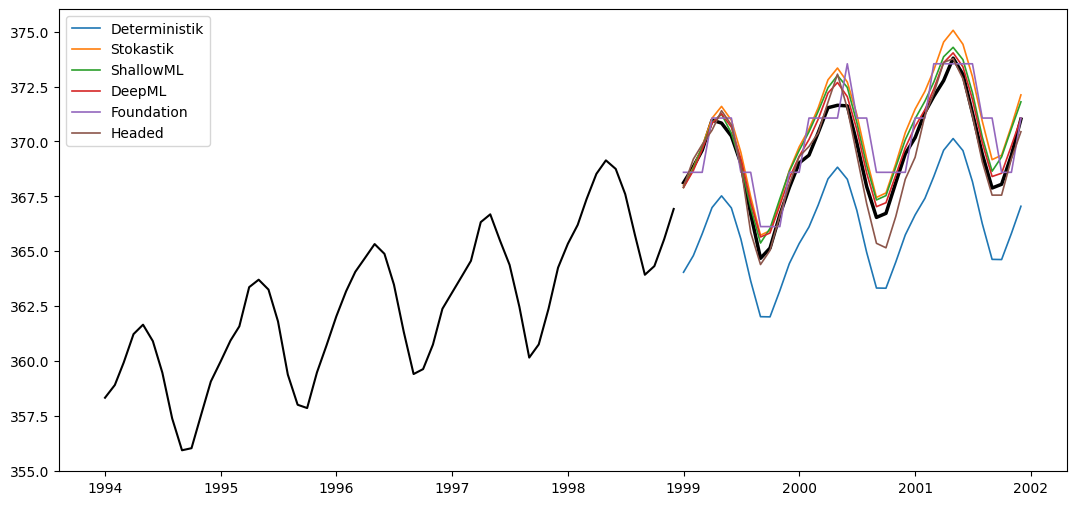

In [16]:
plt.figure(figsize=(13, 6))
plt.plot(train.index[-60:], train.values[-60:], color="black")
plt.plot(test.index, test.values, color="black", linewidth=2.5)
for name, pred in results.items():
    plt.plot(test.index, pred.values, linewidth=1.2, label=name)
plt.legend()
plt.show()

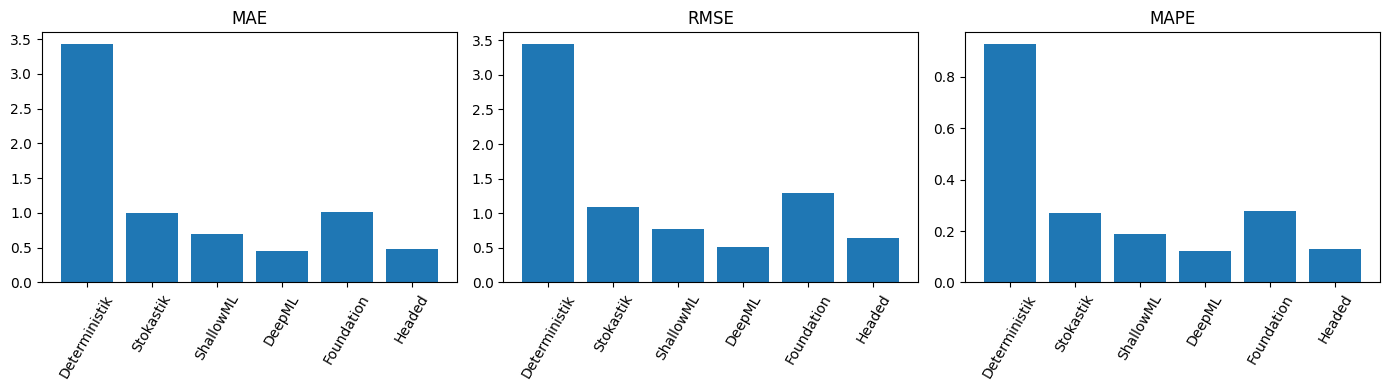

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for j, metric in enumerate(["MAE", "RMSE", "MAPE"]):
    ax[j].bar(scores.index, scores[metric])
    ax[j].set_title(metric)
    ax[j].tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()

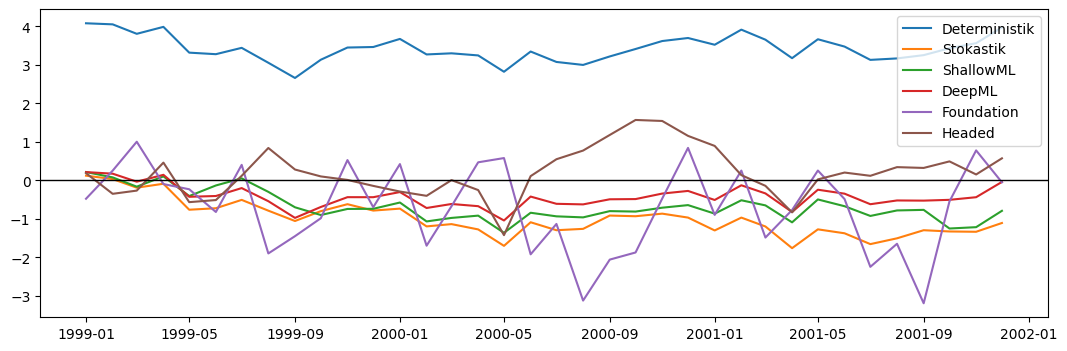

,count,mean,std,min,25%,50%,75%,max
Deterministik,36.0,3.426081,0.338613,2.660497,3.208123,3.421970,3.657112,4.080281
Stokastik,36.0,-0.986970,0.455932,-1.757987,-1.292182,-1.069291,-0.776823,0.124069
ShallowML,36.0,-0.671136,0.389104,-1.359673,-0.915538,-0.751955,-0.509433,0.217873
DeepML,36.0,-0.421325,0.286792,-1.039485,-0.607652,-0.435131,-0.294042,0.216965
Foundation,36.0,-0.695767,1.099771,-3.188939,-1.523028,-0.607047,0.256364,1.004846
Headed,36.0,0.195705,0.625779,-1.419977,-0.168504,0.129247,0.508502,1.570206


In [18]:
residuals = pd.DataFrame(
    {name: test.values - np.asarray(pred, dtype=float) for name, pred in results.items()},
    index=test.index,
)

plt.figure(figsize=(13, 4))
for name in residuals.columns:
    plt.plot(residuals.index, residuals[name], label=name)
plt.axhline(0, color="black", linewidth=1)
plt.legend()
plt.show()

residuals.describe().T